## Cellpose-SAM: superhuman generalization for cellular segmentation

Marius Pachitariu, Michael Rariden, Carsen Stringer

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

This notebook shows how to process your own 2D or 3D images, saved on Google Drive.

This notebook is adapted from the notebook by Pradeep Rajasekhar, inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki).

### Make sure you have GPU access enabled by going to Runtime -> Change Runtime Type -> Hardware accelerator and selecting GPU

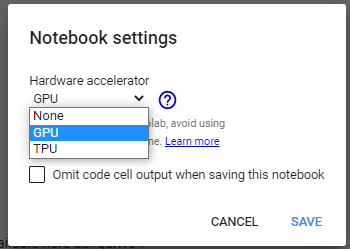

### Install Cellpose-SAM


In [1]:
!pip install git+https://www.github.com/mouseland/cellpose.git

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-resdkp06
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-resdkp06
  Resolved https://www.github.com/mouseland/cellpose.git to commit 71e7e887216c36d06f01ca3e9958a06949980d90
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 54.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 75.6 MB/s eta 0:00:00:00:0100:01
  Created wheel for cellpose: filename=cellpose-4.1.2.dev16+g71e7e8872-py3-none-any.whl size=214482 sha256=827220e31e19b9436d3952be2b28363602446122f2b610d597f5a3416adbf2c2
  Stored in directory: /tmp/pip-ephem-wheel-cache-dzcigd2a/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose


In [ ]:
# Clonar o repositório com o código do projeto
import sys
import os
repo_dir = 'projeto-5-redes-profundas-projeto-v-produtos-industriais'
if not os.path.exists(repo_dir):
    !git clone --branch https://github.com/ICEI-PUC-Minas-PPL-CDIA/projeto-5-redes-profundas-projeto-v-produtos-industriais.git
%cd {repo_dir}
sys.path.append(f"/content/{repo_dir}")

Check GPU and instantiate model - will download weights.

In [2]:
import numpy as np
from cellpose import models, core, io, plot, transforms
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

creating new log file
2026-04-24 11:07:28,728 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-04-24 11:07:28,729 [INFO] 
cellpose version: 	4.1.2.dev16+g71e7e8872 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-04-24 11:07:29,137 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 11:07:29,139 [INFO] ** TORCH CUDA version installed and working. **
2026-04-24 11:07:29,140 [INFO] >>>> using GPU (CUDA)
2026-04-24 11:07:31,668 [INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam" to /root/.cellpose/models/cpsam



100%|██████████| 1.15G/1.15G [00:06<00:00, 190MB/s] 


Input directory with your images:

In [ ]:
# *** change to your google drive folder path ***
dir = "/content/"
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

# *** change to your image extension ***
image_ext = ".tif"

# list all files
files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

if(len(files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} images in folder:")

for f in files:
  print(f.name)

1 images in folder:
TCGA-18-5592-01Z-00-DX1.tif


## Run Cellpose-SAM on one image in folder

Here are some of the parameters you can change:

* ***flow_threshold*** is  the  maximum  allowed  error  of  the  flows  for  each  mask.   The  default  is 0.4.
    *  **Increase** this threshold if cellpose is not returning as many masks as you’d expect (or turn off completely with 0.0)
    *   **Decrease** this threshold if cellpose is returning too many ill-shaped masks.

* ***cellprob_threshold*** determines proability that a detected object is a cell.   The  default  is 0.0.
    *   **Decrease** this threshold if cellpose is not returning as many masks as you’d expect or if masks are too small
    *   **Increase** this threshold if cellpose is returning too many masks esp from dull/dim areas.

* ***tile_norm_blocksize*** determines the size of blocks used for normalizing the image. The default is 0, which means the entire image is normalized together.
  You may want to change this to 100-200 pixels if you have very inhomogeneous brightness across your image.



In [4]:
img = io.imread(files[0])

print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

your image has shape: (1000, 1000, 3). Assuming channel dimension is last with 3 channels


### Channel Selection:

- Use the dropdowns below to select the _zero-indexed_ channels of your image to segment. The order does not matter. Remember to rerun the cell after you edit the dropdowns.

- If you have a histological image taken in brightfield, you don't need to adjust the channels.

- If you have a fluroescent image with multiple stains, you should choose one channel with a cytoplasm/membrane stain, one channel with a nuclear stain, and set the third channel to `None`. Choosing multiple channels may produce segmentaiton of all the structures in the image. If you have retrained the model on your data with a thrid stain (described below), you can run segmentation with all channels.

In [ ]:
first_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = '1' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = '2' # @param ['None', 0, 1, 2, 3, 4, 5]

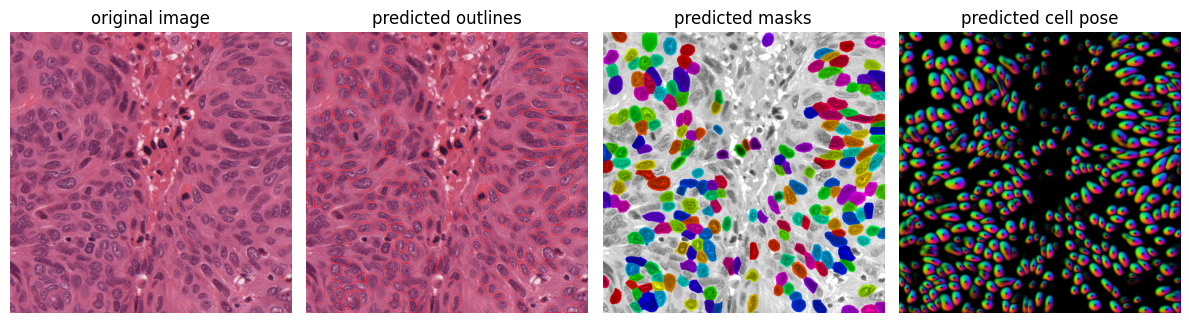

In [6]:
selected_channels = []
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  if int(c) > img.shape[-1]:
    assert False, 'invalid channel index, must have index greater or equal to the number of channels'
  if c != 'None':
    selected_channels.append(int(c))



img_selected_channels = np.zeros_like(img)
img_selected_channels[:, :, :len(selected_channels)] = img[:, :, selected_channels]


flow_threshold = 0.4
cellprob_threshold = -4.0
tile_norm_blocksize = 0

transforms.normalize_img(img, normalize=True, norm3D=True, invert=True, lowhigh=None, percentile=(1.0, 99.0), sharpen_radius=0, smooth_radius=0, tile_norm_blocksize=0, tile_norm_smooth3D=1, axis=-1)

masks, flows, styles = model.eval(img_selected_channels, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize}, diameter=100)

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
plt.tight_layout()
plt.show()


## Run Cellpose-SAM on folder of images

if you have many large images, you may want to run them as a loop over images



In [7]:
masks_ext = ".png" if image_ext == ".png" else ".tif"
for i in trange(len(files)):
    f = files[i]
    img = io.imread(f)
    masks, flows, styles = model.eval(img, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks)

100%|██████████| 1/1 [00:09<00:00,  9.13s/it]


if you have small images, you may want to load all of them first and then run, so that they can be batched together on the GPU

In [8]:
print("loading images")
imgs = [io.imread(files[i]) for i in trange(len(files))]

print("running cellpose-SAM")
masks, flows, styles = model.eval(imgs, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

print("saving masks")
for i in trange(len(files)):
    f = files[i]
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks[i])

loading images


100%|██████████| 1/1 [00:00<00:00, 23.65it/s]

running cellpose-SAM


saving masks


100%|██████████| 1/1 [00:00<00:00, 81.05it/s]


to save your masks for ImageJ, run the following code:

In [9]:
for i in trange(len(files)):
    f = files[i]
    io.imsave(dir / (f.name + "_masks" + masks_ext), masks[i])
    io.save_rois(masks[i], f)

100%|██████████| 1/1 [00:00<00:00,  1.90it/s]


In [ ]:
import numpy as np
import tifffile # Recomendado para salvar múltiplos canais sem perda

# 1. Garante que a máscara tenha a mesma dimensão (H, W, 1) para poder empilhar
# O Cellpose gera 'masks' como (H, W). Precisamos adicionar o eixo do canal.
mask_channel = masks[:, :, np.newaxis]

# 2. Junta a imagem original (3 canais) com a máscara (1 canal)
# 'img' é a sua imagem lida no início do script
img_4_channels = np.concatenate((img, mask_channel), axis=-1)

# Verificação: o shape deve ser (1000, 1000, 4)
print(f"Novo shape da imagem: {img_4_channels.shape}")

# 3. Salva como um arquivo TIFF de 4 canais
# É melhor usar .tif, pois .png de 4 canais é interpretado como RGBA (transparência)
# e pode alterar os valores da sua máscara.
tifffile.imwrite(dir / 'entrada_proxima_rede.tif', img_4_channels.astype('uint16'))

TypeError: list indices must be integers or slices, not tuple